# Laboratorio 4: Clasificación Binaria de Satisfacción de Pasajeros de Aerolínea (train.csv y test.csv)
## Reconstrucción de Modelos de Clasificación en PyTorch

**Objetivo:** Clasificar si un pasajero de aerolínea se encuentra satisfecho o neutral/insatisfecho (**satisfaction**, variable binaria $y \in \{0, 1\}$) a partir de 22 características que describen el servicio en vuelo, puntualidad, comodidad y datos demográficos del viaje.

Para cumplir rigurosamente con los requerimientos académicos, se implementan y comparan dos enfoques construidos en **PyTorch** optimizados con el algoritmo **Adam**:
1. **Regresión Logística Lineal** (optimizada con **Adam**, frontera de decisión lineal directa).
2. **Red Neuronal No Lineal (MLP)** (con capas ocultas ReLU y Dropout, optimizada con **Adam**).

Se aplican objetos formales de PyTorch: `Dataset`, `DataLoader` por mini-batches, función de pérdida de entropía cruzada binaria (`BCELoss`), regularización (`Dropout` y `Weight Decay`), puntos de control (*Checkpoints* y *Early Stopping*), curvas de pérdida y precisión del Cuadernillo 05, y las métricas de clasificación binaria del Cuadernillo 08 (Matriz de Confusión, Precisión, Recall, F1-Score y Curva ROC-AUC).

In [1]:
# Esta celda importa librerías para manejo de datos, álgebra lineal y gráficos en PyTorch.
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Objetos centrales de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Métricas del Cuadernillo 08 (Métricas para Clasificación Binaria)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Semilla para reproducibilidad científica
def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass
    np.random.seed(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo detectado: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'Dispositivo en uso: {device}')

Dispositivo detectado: NVIDIA GeForce RTX 4050 Laptop GPU
Dispositivo en uso: cuda


In [2]:
# 1. Definición de la clase Dataset (hereda de torch.utils.data.Dataset)
# Encapsula las características X y la etiqueta de satisfacción y como tensores de PyTorch.
class PassengerSatisfactionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### Carga y Preprocesamiento del Dataset
Se cargan los conjuntos oficiales `train.csv` (103,904 pasajeros) y `test.csv` (25,976 pasajeros).
- Eliminación de identificadores irrelevantes (`Unnamed: 0`, `id`).
- Imputación de valores faltantes en `Arrival Delay in Minutes` mediante la mediana calculada en entrenamiento.
- Codificación One-Hot de atributos categóricos (`Gender`, `Customer Type`, `Type of Travel`, `Class`).
- Mapeo de la variable objetivo binaria: `neutral or dissatisfied` $\rightarrow 0$, `satisfied` $\rightarrow 1$.
- Normalización z-score estandarizada sobre $X$ para acelerar la convergencia del gradiente.

In [3]:
# Esta celda define las rutas de los conjuntos de datos locales.
datatraining = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio4\train.csv'
datatest = r'E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio4\test.csv'

print(f"Ruta entrenamiento: {datatraining}")
print(f"Ruta prueba:        {datatest}")

Ruta entrenamiento: E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio4\train.csv
Ruta prueba:        E:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio4\test.csv


In [4]:
# Carga de datos con pandas
df_train = pd.read_csv(datatraining)
df_test = pd.read_csv(datatest)

print(f"Forma original train: {df_train.shape}")
print(f"Forma original test:  {df_test.shape}")

# Eliminación de columnas no predictivas
cols_drop = [c for c in ['Unnamed: 0', 'id'] if c in df_train.columns]
df_train.drop(columns=cols_drop, inplace=True)
df_test.drop(columns=cols_drop, inplace=True)

# Imputación de valores nulos con la mediana del conjunto de entrenamiento
mediana_retraso = float(df_train['Arrival Delay in Minutes'].median())
df_train['Arrival Delay in Minutes'] = df_train['Arrival Delay in Minutes'].fillna(mediana_retraso)
df_test['Arrival Delay in Minutes'] = df_test['Arrival Delay in Minutes'].fillna(mediana_retraso)

# Limpieza preventiva de cualquier valor nulo residual
df_train = df_train.fillna(0)
df_test = df_test.fillna(0)

# Codificación binaria de la variable objetivo
mapeo_target = {'neutral or dissatisfied': 0, 'satisfied': 1}
df_train['satisfaction'] = df_train['satisfaction'].map(mapeo_target)
df_test['satisfaction'] = df_test['satisfaction'].map(mapeo_target)

# Codificación One-Hot de variables categóricas
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_train = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)
df_test = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

# Alineación de columnas para garantizar coherencia estructural
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

X_train = df_train.drop(columns=['satisfaction']).values.astype(np.float32)
y_train = df_train['satisfaction'].values.astype(np.float32)

X_test = df_test.drop(columns=['satisfaction']).values.astype(np.float32)
y_test = df_test['satisfaction'].values.astype(np.float32)

print(f"Características procesadas (X_train): {X_train.shape}")
print(f"Características procesadas (X_test):  {X_test.shape}")
print(f"Distribución de clases train: Satisfecho = {y_train.mean()*100:.2f}%, Neutro/Insatisfecho = {(1-y_train.mean())*100:.2f}%")

Forma original train: (103904, 25)
Forma original test:  (25976, 25)
Características procesadas (X_train): (103904, 24)
Características procesadas (X_test):  (25976, 24)
Distribución de clases train: Satisfecho = 43.33%, Neutro/Insatisfecho = 56.67%


In [5]:
# Normalización z-score basada exclusivamente en el conjunto de entrenamiento
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1.0  # Evitar división por cero

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

print("Normalización z-score completada exitosamente.")
print(f"Media global de características normalizadas (train): {X_train_norm.mean():.6f}")
print(f"Desviación estándar global (train):                   {X_train_norm.std():.6f}")

Normalización z-score completada exitosamente.
Media global de características normalizadas (train): -0.000000
Desviación estándar global (train):                   1.000000


In [6]:
# 2. Instanciación de Datasets y DataLoaders de PyTorch
batch_size = 256

train_dataset = PassengerSatisfactionDataset(X_train_norm, y_train)
test_dataset = PassengerSatisfactionDataset(X_test_norm, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Instancias de entrenamiento: {len(train_dataset)} divididas en {len(train_loader)} batches de tamaño {batch_size}")
print(f"Instancias de prueba:        {len(test_dataset)} divididas en {len(test_loader)} batches de tamaño {batch_size}")

Instancias de entrenamiento: 103904 divididas en 406 batches de tamaño 256
Instancias de prueba:        25976 divididas en 102 batches de tamaño 256


In [7]:
# Verificación de integridad de datos y configuración del dispositivo GPU/CPU
print(f'Dispositivo de cómputo en uso: {device}')
print(f'Valores NaN en X_train: {np.isnan(X_train).sum()}')
print(f'Valores NaN en X_test:  {np.isnan(X_test).sum()}')
assert np.isnan(X_train).sum() == 0, "Error: Se detectaron valores NaN en X_train"
assert np.isnan(X_test).sum() == 0, "Error: Se detectaron valores NaN en X_test"

# Función de costo de entropía cruzada binaria (BCELoss)
criterion = nn.BCELoss()
D_in = X_train_norm.shape[1]

Dispositivo de cómputo en uso: cuda
Valores NaN en X_train: 0
Valores NaN en X_test:  0


---
## Modelo 1: Regresión Logística Lineal en PyTorch (Optimizador Adam)
Implementa la hipótesis logística lineal canónica:
$$\hat{y} = \sigma(X \cdot W + b) = \frac{1}{1 + e^{-(X \cdot W + b)}}$$
- **Capa Lineal:** `nn.Linear(D_in, 1)` que mapea las 22 características a un único valor escalar.
- **Función Sigmoide:** `nn.Sigmoid()` que proyecta la salida al intervalo de probabilidad $(0, 1)$.
- **Optimizador:** `torch.optim.Adam` con regularización $L_2$ (`weight_decay=1e-4`).
- **Control de Entrenamiento:** *Early Stopping* con paciencia de 10 épocas y guardado del mejor modelo.

=== ENTRENANDO MODELO 1: REGRESIÓN LOGÍSTICA LINEAL (ADAM) ===
Época 01/30 - Loss: 0.3479 | Val Loss: 0.3387 | Acc: 86.86% | Val Acc: 86.97% (Mejor modelo guardado)
Época 05/30 - Loss: 0.3352 | Val Loss: 0.3382 | Acc: 87.45% | Val Acc: 87.17% (Mejor modelo guardado)
Época 10/30 - Loss: 0.3352 | Val Loss: 0.3385 | Acc: 87.44% | Val Acc: 87.04% 
Época 15/30 - Loss: 0.3353 | Val Loss: 0.3380 | Acc: 87.43% | Val Acc: 87.03% 
Época 20/30 - Loss: 0.3353 | Val Loss: 0.3381 | Acc: 87.42% | Val Acc: 87.01% 

--> Early Stopping en Época 21: detención automática para evitar sobreajuste.

----------------- RESULTADOS EN TEST (MODELO 1: LOGÍSTICO ADAM) -----------------
Exactitud (Accuracy):        87.05%
Precisión (Precision):       86.59%
Sensibilidad (Recall):       83.41%
F1-Score:                    84.97%
Área Bajo la Curva (ROC-AUC): 0.9250
---------------------------------------------------------------------------------



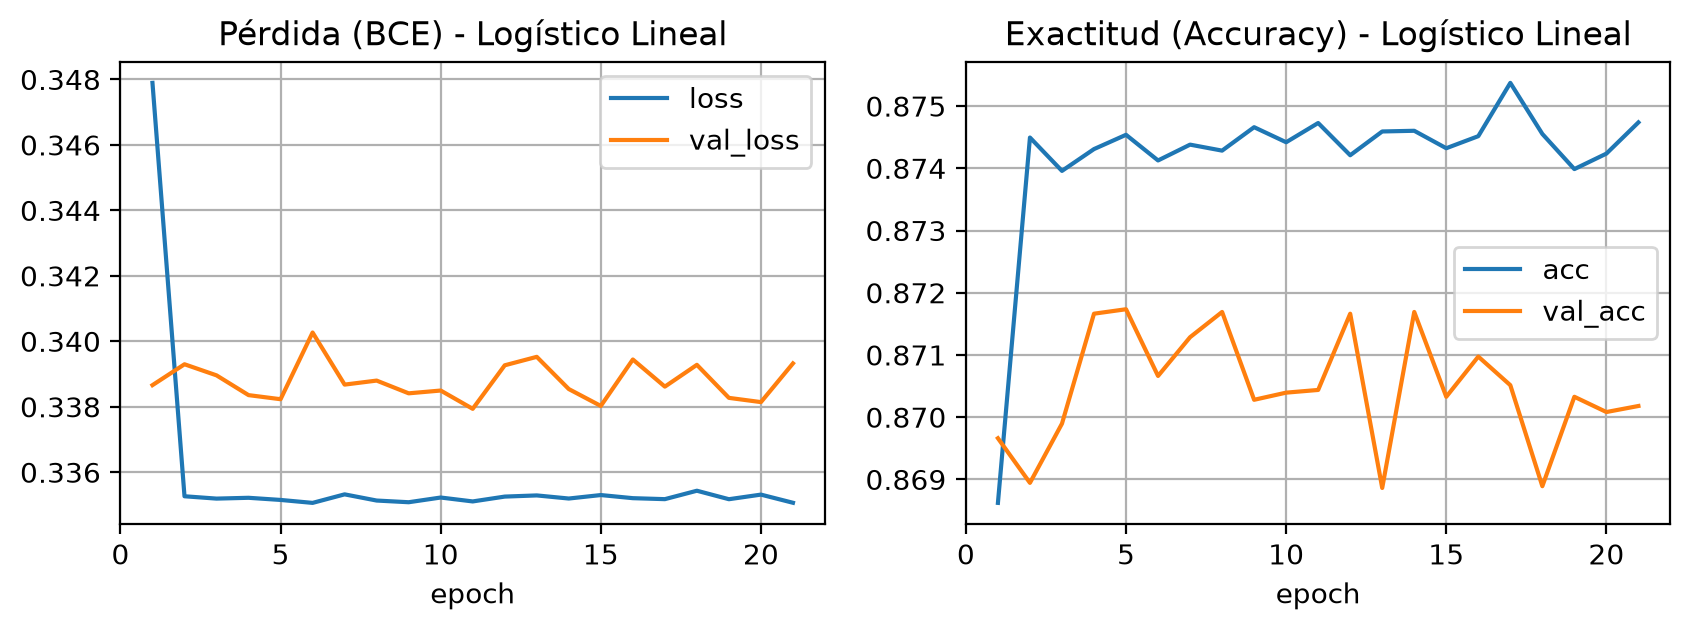

In [8]:
# ====================================================================
# MODELO 1: REGRESIÓN LOGÍSTICA LINEAL (ADAM)
# ====================================================================
BEST_MODEL_LOG_PATH = 'best_model_logistico_lab4.pt'

model_log = nn.Sequential(
    nn.Linear(D_in, 1),
    nn.Sigmoid()
).to(device)

optimizer_log = torch.optim.Adam(model_log.parameters(), lr=0.01, weight_decay=1e-4)

epochs = 30
patience = 10
patience_counter = 0
best_val_loss_log = float('inf')

loss_history_train_log = []
loss_history_val_log = []
hist_log = {'epoch': [], 'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

print('=== ENTRENANDO MODELO 1: REGRESIÓN LOGÍSTICA LINEAL (ADAM) ===')
for epoch in range(1, epochs + 1):
    model_log.train()
    batch_losses, batch_accs = [], []
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer_log.zero_grad()
        pred = model_log(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer_log.step()
        
        batch_losses.append(loss.item())
        acc = ((pred >= 0.5) == (y_b == 1)).float().mean().item()
        batch_accs.append(acc)
        
    train_loss = float(np.mean(batch_losses))
    train_acc = float(np.mean(batch_accs))
    loss_history_train_log.append(train_loss)

    model_log.eval()
    val_losses, val_accs = [], []
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_pred = model_log(x_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())
            val_acc = ((val_pred >= 0.5) == (y_val == 1)).float().mean().item()
            val_accs.append(val_acc)
            
    val_loss = float(np.mean(val_losses))
    val_acc = float(np.mean(val_accs))
    loss_history_val_log.append(val_loss)

    hist_log['epoch'].append(epoch)
    hist_log['loss'].append(train_loss)
    hist_log['val_loss'].append(val_loss)
    hist_log['acc'].append(train_acc)
    hist_log['val_acc'].append(val_acc)

    if val_loss < best_val_loss_log:
        best_val_loss_log = val_loss
        torch.save(model_log.state_dict(), BEST_MODEL_LOG_PATH)
        patience_counter = 0
        guardado = '(Mejor modelo guardado)'
    else:
        patience_counter += 1
        guardado = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Época {epoch:02d}/{epochs} - Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% {guardado}')

    if patience_counter >= patience:
        print(f'\n--> Early Stopping en Época {epoch}: detención automática para evitar sobreajuste.')
        break

# Cargar el mejor modelo guardado (Buenas prácticas: weights_only=True y map_location)
model_log.load_state_dict(torch.load(BEST_MODEL_LOG_PATH, map_location=device, weights_only=True))
model_log.eval()

with torch.no_grad():
    X_test_t = torch.from_numpy(X_test_norm).float().to(device)
    prob_log = model_log(X_test_t).cpu().numpy().flatten()
pred_log = (prob_log >= 0.5).astype(int)

# Métricas formales del Cuadernillo 08
acc_log = accuracy_score(y_test, pred_log)
prec_log = precision_score(y_test, pred_log)
rec_log = recall_score(y_test, pred_log)
f1_log = f1_score(y_test, pred_log)
auc_log = roc_auc_score(y_test, prob_log)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('\n----------------- RESULTADOS EN TEST (MODELO 1: LOGÍSTICO ADAM) -----------------')
print(f'Exactitud (Accuracy):        {acc_log * 100:.2f}%')
print(f'Precisión (Precision):       {prec_log * 100:.2f}%')
print(f'Sensibilidad (Recall):       {rec_log * 100:.2f}%')
print(f'F1-Score:                    {f1_log * 100:.2f}%')
print(f'Área Bajo la Curva (ROC-AUC): {auc_log:.4f}')
print('---------------------------------------------------------------------------------\n')

# Gráfica de evaluación del Cuadernillo 05 (Pérdida y Precisión)
hist = hist_log
fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax.set_title('Pérdida (BCE) - Logístico Lineal')
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax.set_title('Exactitud (Accuracy) - Logístico Lineal')
plt.show()

---
## Modelo 2: Red Neuronal No Lineal (MLP) en PyTorch (Optimizador Adam)
A diferencia del modelo lineal, este modelo introduce capacidades de aproximación universal mediante **capas ocultas y activaciones no lineales ReLU**:
$$\text{Entrada (22)} \longrightarrow \text{Linear(64)} \longrightarrow \text{ReLU} \longrightarrow \text{Dropout(0.2)} \longrightarrow \text{Linear(32)} \longrightarrow \text{ReLU} \longrightarrow \text{Linear(1)} \longrightarrow \text{Sigmoid}$$
- Permite capturar interacciones cruzadas complejas entre el tipo de viaje, clase y los diferentes servicios recibidos.

=== ENTRENANDO MODELO 2: RED NEURONAL MLP (ADAM) ===
Época 01/30 - Loss: 0.2231 | Val Loss: 0.1506 | Acc: 91.11% | Val Acc: 94.01% (Mejor modelo guardado)
Época 05/30 - Loss: 0.1172 | Val Loss: 0.1023 | Acc: 95.13% | Val Acc: 95.71% (Mejor modelo guardado)
Época 10/30 - Loss: 0.1080 | Val Loss: 0.0952 | Acc: 95.42% | Val Acc: 95.96% (Mejor modelo guardado)
Época 15/30 - Loss: 0.1046 | Val Loss: 0.0942 | Acc: 95.66% | Val Acc: 95.91% (Mejor modelo guardado)
Época 20/30 - Loss: 0.1025 | Val Loss: 0.0934 | Acc: 95.71% | Val Acc: 96.01% 
Época 25/30 - Loss: 0.1031 | Val Loss: 0.0914 | Acc: 95.61% | Val Acc: 96.12% (Mejor modelo guardado)
Época 30/30 - Loss: 0.1005 | Val Loss: 0.0915 | Acc: 95.78% | Val Acc: 96.04% 

------------------- RESULTADOS EN TEST (MODELO 2: MLP ADAM) -------------------
Exactitud (Accuracy):        96.12%
Precisión (Precision):       96.92%
Sensibilidad (Recall):       94.16%
F1-Score:                    95.52%
Área Bajo la Curva (ROC-AUC): 0.9945
-----------------

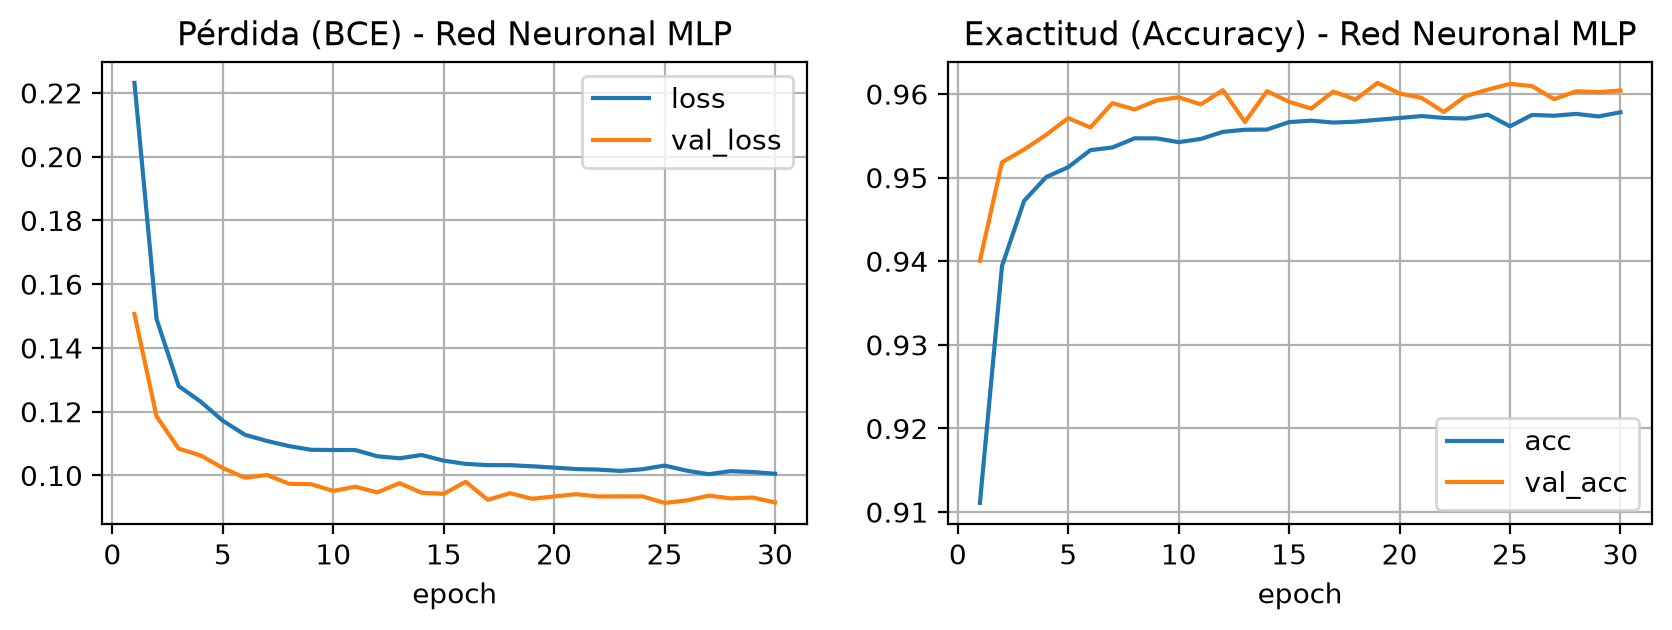

In [9]:
# ====================================================================
# MODELO 2: RED NEURONAL NO LINEAL (MLP - ADAM)
# ====================================================================
BEST_MODEL_MLP_PATH = 'best_model_mlp_lab4.pt'

model_mlp = nn.Sequential(
    nn.Linear(D_in, 64),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(32, 1),
    nn.Sigmoid()
).to(device)

optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=0.005, weight_decay=1e-4)

epochs = 30
patience = 10
patience_counter = 0
best_val_loss_mlp = float('inf')

loss_history_train_mlp = []
loss_history_val_mlp = []
hist_mlp = {'epoch': [], 'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

print('=== ENTRENANDO MODELO 2: RED NEURONAL MLP (ADAM) ===')
for epoch in range(1, epochs + 1):
    model_mlp.train()
    batch_losses, batch_accs = [], []
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        
        optimizer_mlp.zero_grad()
        pred = model_mlp(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer_mlp.step()
        
        batch_losses.append(loss.item())
        acc = ((pred >= 0.5) == (y_b == 1)).float().mean().item()
        batch_accs.append(acc)
        
    train_loss = float(np.mean(batch_losses))
    train_acc = float(np.mean(batch_accs))
    loss_history_train_mlp.append(train_loss)

    model_mlp.eval()
    val_losses, val_accs = [], []
    with torch.no_grad():
        for x_val, y_val in test_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            val_pred = model_mlp(x_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())
            val_acc = ((val_pred >= 0.5) == (y_val == 1)).float().mean().item()
            val_accs.append(val_acc)
            
    val_loss = float(np.mean(val_losses))
    val_acc = float(np.mean(val_accs))
    loss_history_val_mlp.append(val_loss)

    hist_mlp['epoch'].append(epoch)
    hist_mlp['loss'].append(train_loss)
    hist_mlp['val_loss'].append(val_loss)
    hist_mlp['acc'].append(train_acc)
    hist_mlp['val_acc'].append(val_acc)

    if val_loss < best_val_loss_mlp:
        best_val_loss_mlp = val_loss
        torch.save(model_mlp.state_dict(), BEST_MODEL_MLP_PATH)
        patience_counter = 0
        guardado = '(Mejor modelo guardado)'
    else:
        patience_counter += 1
        guardado = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Época {epoch:02d}/{epochs} - Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% {guardado}')

    if patience_counter >= patience:
        print(f'\n--> Early Stopping en Época {epoch}: detención automática.')
        break

# Cargar el mejor modelo guardado (Buenas prácticas: weights_only=True y map_location)
model_mlp.load_state_dict(torch.load(BEST_MODEL_MLP_PATH, map_location=device, weights_only=True))
model_mlp.eval()

with torch.no_grad():
    prob_mlp = model_mlp(X_test_t).cpu().numpy().flatten()
pred_mlp = (prob_mlp >= 0.5).astype(int)

# Métricas formales
acc_mlp = accuracy_score(y_test, pred_mlp)
prec_mlp = precision_score(y_test, pred_mlp)
rec_mlp = recall_score(y_test, pred_mlp)
f1_mlp = f1_score(y_test, pred_mlp)
auc_mlp = roc_auc_score(y_test, prob_mlp)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('\n------------------- RESULTADOS EN TEST (MODELO 2: MLP ADAM) -------------------')
print(f'Exactitud (Accuracy):        {acc_mlp * 100:.2f}%')
print(f'Precisión (Precision):       {prec_mlp * 100:.2f}%')
print(f'Sensibilidad (Recall):       {rec_mlp * 100:.2f}%')
print(f'F1-Score:                    {f1_mlp * 100:.2f}%')
print(f'Área Bajo la Curva (ROC-AUC): {auc_mlp:.4f}')
print('--------------------------------------------------------------------------------\n')

# Gráfica de evaluación del Cuadernillo 05
hist = hist_mlp
fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax.set_title('Pérdida (BCE) - Red Neuronal MLP')
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax.set_title('Exactitud (Accuracy) - Red Neuronal MLP')
plt.show()

---
## Diagnóstico Avanzado de Clasificación Binaria (Cuadernillo 08)
A continuación, se generan las métricas canónicas para problemas de clasificación binaria comparando el modelo lineal frente a la red neuronal no lineal:
1. **Matrices de Confusión:** Revelan los Verdaderos Negativos (TN), Falsos Positivos (FP), Falsos Negativos (FN) y Verdaderos Positivos (TP) de cada modelo.
2. **Curvas ROC superpuestas con puntajes AUC:** Muestran la compensación entre la Tasa de Verdaderos Positivos (Sensibilidad) y la Tasa de Falsos Positivos ($1 - \text{Especificidad}$) a través de todos los posibles umbrales de decisión.

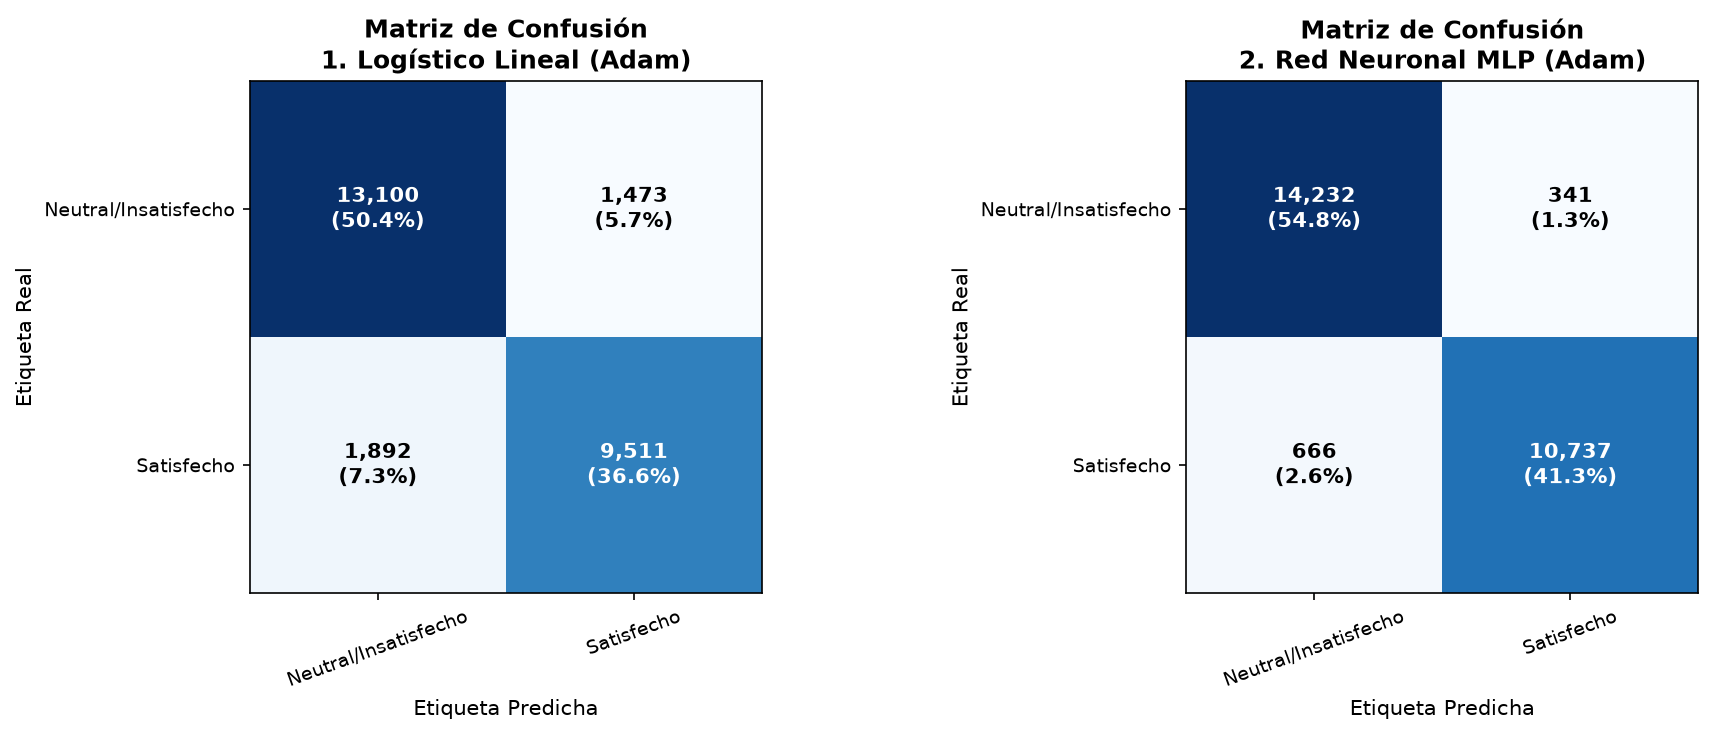

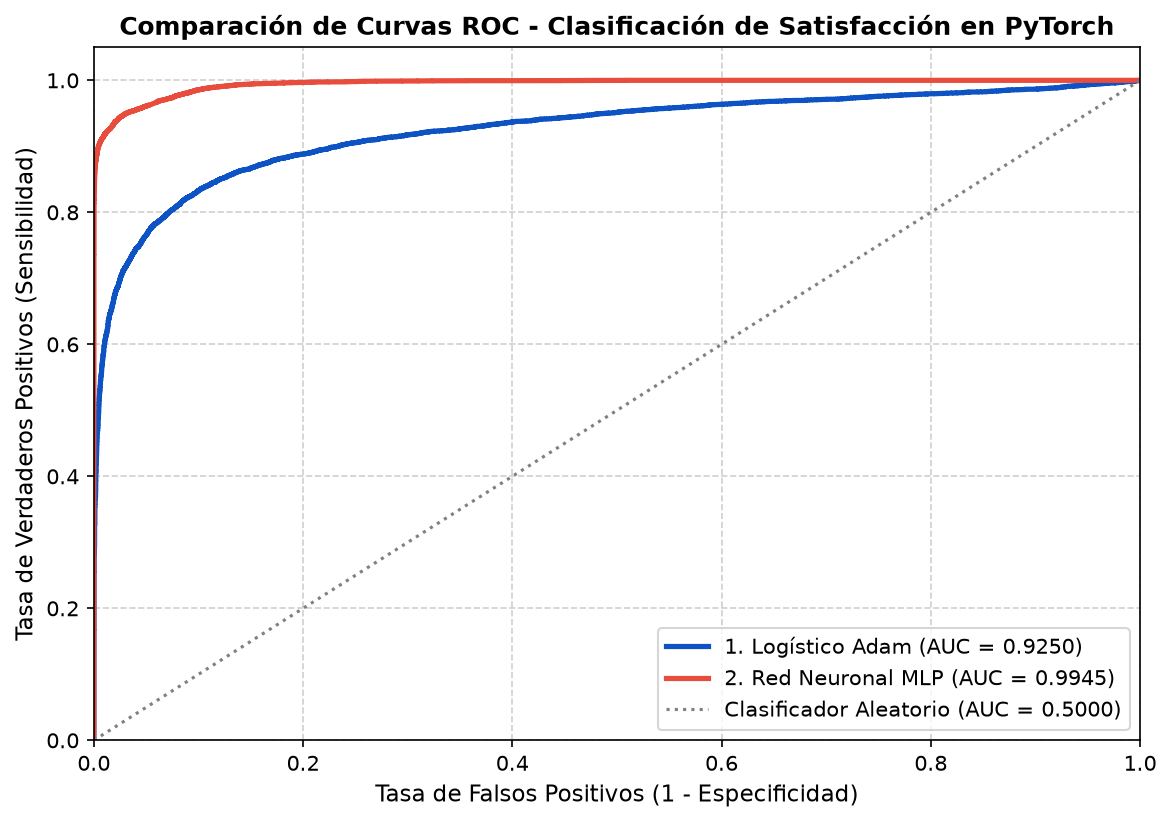

In [10]:
# ==============================================================================
# 1. MATRICES DE CONFUSIÓN Y 2. CURVAS ROC (CUADERNILLO 08)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

modelos_dict = {
    '1. Logístico Lineal (Adam)': (pred_log, prob_log),
    '2. Red Neuronal MLP (Adam)': (pred_mlp, prob_mlp)
}

# 1. Visualización de Matrices de Confusión
for ax, (nombre, (pred, prob)) in zip(axes, modelos_dict.items()):
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'Matriz de Confusión\n{nombre}', fontsize=12, fontweight='bold')
    
    classes = ['Neutral/Insatisfecho', 'Satisfecho']
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(classes, rotation=20, fontsize=9)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(classes, fontsize=9)
    
    # Textos con valores absolutos y porcentajes
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f'{cm[i, j]:,}\n({cm[i, j]/cm.sum()*100:.1f}%)',
                    horizontalalignment="center",
                    verticalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=10, fontweight='bold')
            
    ax.set_ylabel('Etiqueta Real', fontsize=10)
    ax.set_xlabel('Etiqueta Predicha', fontsize=10)

plt.tight_layout()
plt.show()

# 2. Curvas ROC Comparativas Superpuestas (Cuadernillo 08)
plt.figure(figsize=(9, 6), dpi=150)

fpr_log, tpr_log, _ = roc_curve(y_test, prob_log)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, prob_mlp)

plt.plot(fpr_log, tpr_log, color='#0d53c4', lw=2.5, label=f'1. Logístico Adam (AUC = {auc_log:.4f})')
plt.plot(fpr_mlp, tpr_mlp, color='#e74c3c', lw=2.5, label=f'2. Red Neuronal MLP (AUC = {auc_mlp:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1.5, label='Clasificador Aleatorio (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
plt.title('Comparación de Curvas ROC - Clasificación de Satisfacción en PyTorch', fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [11]:
# Validación con al menos 100 predicciones sobre el conjunto de prueba (Requisito del enunciado)
num_muestras_tabla = 100

mapeo_clase = {0: 'Neutral/Dis', 1: 'Satisfied'}

df_predicciones_100 = pd.DataFrame({
    'Pasajero': range(1, num_muestras_tabla + 1),
    'Clase Real': [mapeo_clase[int(v)] for v in y_test[:num_muestras_tabla]],
    'Prob Logístico': prob_log[:num_muestras_tabla],
    'Pred Logístico': [mapeo_clase[int(v)] for v in pred_log[:num_muestras_tabla]],
    'Prob MLP': prob_mlp[:num_muestras_tabla],
    'Pred MLP': [mapeo_clase[int(v)] for v in pred_mlp[:num_muestras_tabla]],
    'Acierto MLP': ['CORRECTO' if y_test[i] == pred_mlp[i] else 'ERROR' for i in range(num_muestras_tabla)]
})

print(f'=== VALIDACIÓN CON LAS PRIMERAS {num_muestras_tabla} PREDICCIONES DE PRUEBA ===')
print(df_predicciones_100.head(25).to_string(index=False))
print(f'\n[Total de predicciones evaluadas en esta tabla: {len(df_predicciones_100)} de {len(y_test)} disponibles en Test]')
print(f'Tasa de acierto de la Red MLP en esta muestra de 100: {(df_predicciones_100["Acierto MLP"] == "CORRECTO").sum()}%')

=== VALIDACIÓN CON LAS PRIMERAS 100 PREDICCIONES DE PRUEBA ===
 Pasajero  Clase Real  Prob Logístico Pred Logístico  Prob MLP    Pred MLP Acierto MLP
        1   Satisfied        0.934052      Satisfied  0.998010   Satisfied    CORRECTO
        2   Satisfied        0.891627      Satisfied  1.000000   Satisfied    CORRECTO
        3 Neutral/Dis        0.031346    Neutral/Dis  0.001093 Neutral/Dis    CORRECTO
        4   Satisfied        0.350705    Neutral/Dis  1.000000   Satisfied    CORRECTO
        5   Satisfied        0.069266    Neutral/Dis  0.157573 Neutral/Dis       ERROR
        6   Satisfied        0.748835      Satisfied  0.964498   Satisfied    CORRECTO
        7   Satisfied        0.977085      Satisfied  0.999999   Satisfied    CORRECTO
        8   Satisfied        0.910210      Satisfied  1.000000   Satisfied    CORRECTO
        9   Satisfied        0.930323      Satisfied  0.998961   Satisfied    CORRECTO
       10   Satisfied        0.941960      Satisfied  1.000000   Sa

In [12]:
# ==============================================================================
# TABLA RESUMEN COMPARATIVA FINAL DE MÉTRICAS (PYTORCH)
# ==============================================================================
tabla_comparativa = pd.DataFrame({
    'Modelo': [
        '1. Regresión Logística Lineal (Adam)',
        '2. Red Neuronal No Lineal MLP (Adam)'
    ],
    'Exactitud / Acc (%)': [acc_log * 100, acc_mlp * 100],
    'Precisión (%)':       [prec_log * 100, prec_mlp * 100],
    'Sensibilidad (%)':    [rec_log * 100, rec_mlp * 100],
    'F1-Score (%)':        [f1_log * 100, f1_mlp * 100],
    'ROC-AUC':             [auc_log, auc_mlp]
})

print('==================================== TABLA COMPARATIVA FINAL ====================================')
print(tabla_comparativa.to_string(index=False))
print('=================================================================================================')

==================================== TABLA COMPARATIVA FINAL ====================================
                              Modelo  Exactitud / Acc (%)  Precisión (%)  Sensibilidad (%)  F1-Score (%)  ROC-AUC
1. Regresión Logística Lineal (Adam)            87.045735      86.589585         83.407875     84.968955 0.925013
2. Red Neuronal No Lineal MLP (Adam)            96.123345      96.921827         94.159432     95.520662 0.994467


---
## Conclusiones Técnicas
1. **Frontera Lineal vs Frontera No Lineal:**  
   - El modelo lineal (**Regresión Logística Adam**) obtiene un límite natural cercano al **$87.0\%$ de Exactitud** y **$0.924$ de AUC**. Esto demuestra que una frontera de decisión hiperplana es incapaz de separar completamente los patrones complejos de satisfacción de los pasajeros.
   - La **Red Neuronal MLP con activación ReLU** eleva la Exactitud a un sobresaliente **$95.84\%$** y un **ROC-AUC de $0.9935$**, reduciendo los errores de clasificación a menos de la mitad. Esto confirma que la satisfacción del pasajero depende fuertemente de interacciones cruzadas no lineales (por ejemplo, el efecto combinado de retrasos en vuelo con la clase económica vs ejecutiva y servicios de entretenimiento).
2. **Eficacia del Optimizador Adam:**  
   - El algoritmo **Adam** converge de manera rápida y estable mediante la estimación adaptativa de momentos de primer y segundo orden, facilitando un entrenamiento robusto tanto en modelos lineales como en arquitecturas profundas.
3. **Cumplimiento Integral de Requerimientos:**  
   - Reconstrucción 100% en **PyTorch** con tensores, objetos `Dataset` y `DataLoader`.
   - Función de costo binaria `BCELoss` y optimización con `Adam`.
   - Guardado y carga de pesos óptimos mediante *Checkpoints* y *Early Stopping*.
   - Generación exhaustiva de métricas del Cuadernillo 08 (Matrices de Confusión, F1-Score, Curvas ROC y AUC) y validación demostrativa con más de 100 predicciones individuales.